# N09 — Tire Degradation TCN: Global Model

**Goal:** Train a causal TCN to predict tire degradation from race telemetry — and figure out what prediction target actually makes sense.

## What we built

The target variable is `FuelAdjustedDegAbsolute`: cumulative seconds lost to tyre wear since lap 1 of the stint, with the fuel load effect removed. A value of 1.2 s means the tyre is currently 1.2 s slower than on lap 1 — purely rubber degradation. Predicting this one step ahead (lap t+1 from laps 1..t) is the core task.

The model is a **causal TCN** (Temporal Convolutional Network): a stack of dilated, causal convolutions with residual connections, trained with PyTorch Lightning. Inputs are sequences of up to 28 laps; the model predicts one step ahead at each lap.

## How the approach evolved

We started simple: one global model, one prediction per stint (per-stint sampling), cumulative target. Results were poor — val/MAE ≈ 1.56 s, R² ≈ 0.50. The root cause was data starvation: with only ~1,081 training sequences, each epoch ran fewer than 10 gradient steps.

The fix was **per-lap sampling**: instead of one sample per stint, every prefix of a stint becomes a training sample (laps 1..t → predict lap t+1, for all t). That turned ~1,081 sequences into ~20,363 — a 20× increase with no new data collection. Val/MAE dropped to 0.87 s immediately.

That insight also motivated splitting into **two separate models** rather than one:

## Two-model architecture

| | Model A | Model B |
|---|---|---|
| Target | `FuelAdjustedDegAbsolute[t]` — cumulative degradation | `ΔFuelAdjustedDegAbsolute[t]` — per-lap increment |
| Feature set | Production (42 features, Cat2 + Cat3) | Pure (Cat3 only) |
| HuberLoss δ | 1.0 s | 0.1 s (calibrated to incremental scale) |
| Fine-tuning | Global here → per-compound in N10 | Global only |
| Output role | Strategy simulation — total degradation at lap t | `tcn_wear_rate`: forward-looking wear rate as feature |

Model B's `tcn_wear_rate` is fundamentally different from the existing `DegradationRate` feature (a noisy 3-lap rolling polyfit): it uses 28 laps of sequential context, is physically informed by the full stint trajectory, and has no circular dependency with N06 XGBoost (which uses `DegradationRate`, not `tcn_wear_rate`).

## Training protocol

Both models follow the same two-phase approach:
- **Phase 1** — train=2023, val=2024: determines early-stop epoch, validates hyperparameters
- **Phase 2** — train=2023+2024, test=2025: definitive numbers for the TFG

**Inputs:** `laps_tiredeg.parquet` · `tiredeg_sequence_config.json` · `tiredeg_feature_manifest.json`
**Outputs:** `tiredeg_tcn_modelA.ckpt` · `tiredeg_tcn_modelB.ckpt` · `tiredeg_scaler.pkl` · `tiredeg_model_config.json`

---

| Step | |
|------|-|
| 0 | Imports and environment setup |
| 1 | Load data, sequence config and feature sets |
| 2 | Dataset, normalization and DataModule |
| 3 | Model architecture: `CausalConv1dBlock` → `TCNResidualBlock` → `TireDegTCN` |
| 4 | `TireDegLitModule`: loss, metrics and optimizer |
| 5 | Architecture profiling and GPU memory analysis |
| 6 | Model A — Phase 1a: production features, cumulative target, train=2023 |
| 7 | Model B — Phase 1 + Phase 2: pure features, incremental target |
| 8 | Model A — Phase 2: final model, train=2023+2024, test=2025 |
| 9 | Diagnostics: residuals by compound, circuit and tyre age |
| 10 | Save weights, scaler and config for N10 |


---

## Step 0 — Imports, Path Setup & GPU Detection


- **GPU:** NVIDIA GeForce RTX 5070 Laptop GPU (8.5 GB VRAM). All training phases
  run on CUDA; CPU is used only as fallback for inference without GPU access.
- **Torch 2.10.0+cu128** — CUDA 12.8 build, compatible with the Blackwell architecture of
  the RTX 5070. The `+cu128` suffix confirms this is not the default CPU-only PyPI wheel.
- **Lightning 2.6.1** — handles the training loop, checkpointing, early stopping and logging,
  keeping model code free of boilerplate.
- **Seed 42** fixed via `L.seed_everything(workers=True)

In [1]:
import json
import warnings
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import lightning as L
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor,
)
from lightning.pytorch.loggers import CSVLogger

import torchmetrics

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})

# ── Paths ──────────────────────────────────────────────────────────────────────
repo_root = Path.cwd()
while not (repo_root / '.git').exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

processed_path = repo_root / 'data' / 'processed'
models_path    = repo_root / 'data' / 'models'
models_path.mkdir(parents=True, exist_ok=True)
outputs_path   = Path.cwd() / 'outputs'
outputs_path.mkdir(parents=True, exist_ok=True)


In [2]:
# ── Reproducibility ────────────────────────────────────────────────────────────
L.seed_everything(42, workers=True)

# ── Device ─────────────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('Device: CPU')

print(f'\nTorch     : {torch.__version__}')
print(f'Lightning : {L.__version__}')
print(f'Repo root : {repo_root}')
print(f'Models    : {models_path}')

Seed set to 42


GPU : NVIDIA GeForce RTX 5070 Laptop GPU
VRAM: 8.5 GB

Torch     : 2.10.0+cu128
Lightning : 2.6.1
Repo root : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
Models    : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models


---

## Step 1 — Load Data & Config

Three artefacts produced by upstream notebooks feed into N09:

- `laps_tiredeg.parquet` (N07) — 68,122 laps across 2023–2025, enriched with
  `AbsoluteCompound` (C1–C6) and all degradation features
- `tiredeg_sequence_config.json` (N08) — global window size and per-compound window sizes
  derived from p90 stint length distributions
- `tiredeg_feature_manifest.json` (N07) — canonical feature lists for the production and
  pure input sets, with the leakage audit embedded

The feature manifest defines two mutually exclusive exclusion sets:
- **Production model** — drops only the four truly leaky columns that directly encode the target
- **Pure model** — additionally drops the ten lap-time shortcuts (Category 2), leaving only
  exogenous physical features as inputs. This model is made for research purposes only, **unless** its performance is close to the production model. In that case, I will use this model as it represents more closely the conditions F1 teams have for developing a tire degradation model.


First, we need to load our tiredeg parquet. We also do a brief sanity check.

In [3]:
# ── 1. Lap data ────────────────────────────────────────────────────────────────
df = pd.read_parquet(processed_path / 'laps_tiredeg.parquet')
print(f'Laps      : {len(df):,}')
print(f'Columns   : {len(df.columns)}')
print(f'Years     : {sorted(df["Year"].unique())}')
print(f'Compounds : {sorted(df["AbsoluteCompound"].dropna().unique())}')
print(f'\nBy year:')
print(df.groupby('Year').size().rename('laps').to_string())

Laps      : 68,122
Columns   : 56
Years     : [2023, 2024, 2025]
Compounds : ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']

By year:
Year
2023    22106
2024    23256
2025    22760


- **68,122 laps** across 3 seasons and 6 absolute compounds load cleanly. Year counts
  are balanced (22–23k per season), confirming no partial-season gaps in the parquet.
- **C6 is present** in the data but has no per-compound window in the config — it falls
  back to the global model at inference time, as established in N08 (only 4 stints, statistically
  unusable for a dedicated fine-tuned model).

Now we configure the different window sizes that our models will use. We take these values from our `tiredeg_sequence_config.json`.

In [4]:
# ── 2. Sequence config ─────────────────────────────────────────────────────────
with open(processed_path / 'tiredeg_sequence_config.json', encoding='utf-8') as f:
    seq_cfg = json.load(f)

GLOBAL_WINDOW = seq_cfg['global']['window_size']
PER_COMPOUND_WINDOWS = {
    c: v['window_size']
    for c, v in seq_cfg['per_compound'].items()
    if v['window_size'] is not None
}

print(f'\nGlobal window size : {GLOBAL_WINDOW} laps')
print(f'Per-compound windows:')
for c, w in PER_COMPOUND_WINDOWS.items():
    print(f'  {c}: {w}')


Global window size : 28 laps
Per-compound windows:
  C1: 25
  C2: 31
  C3: 30
  C4: 26
  C5: 22


- **Global window = 36 laps** (p90 of all dry stints). Per-compound windows range from 31
  (C1, C5) to 40 (C2), calibrated individually in N08 to avoid unnecessary truncation on
  compounds with characteristically longer stints.

Now we load our feature manifest. With this technique, we don't have to persists csvs with our clean data, usually meaning more storage and more files to manage. 

We just simply import a json that tells the dataframe wich values need modifications, pruning or our target variable.

In [5]:
# ── 3. Feature manifest ────────────────────────────────────────────────────────
with open(processed_path / 'tiredeg_feature_manifest.json', encoding='utf-8') as f:
    feat_manifest = json.load(f)

TARGET = feat_manifest['target']
LEAKY  = set(feat_manifest['leaky_columns'])

LAPTIME_SHORTCUTS = {
    'LapTime_s', 'DegradationRate', 'DegAcceleration',
    'LapTime_Delta', 'Prev_LapTime', 'LapTime_Trend',
    'lap_time_vs_cluster_mean', 'Sector1_s', 'Sector2_s', 'Sector3_s',
}

# Year is kept as a feature (not an ID col) — acts as a concept-drift anchor.
# Pirelli compound formulations and car performance evolve season-to-season;
# including Year lets the model learn season-specific degradation offsets,
# matching the approach used in the lap time prediction model (N05/N06).
ID_COLS = {
    'Driver', 'DriverNumber', 'Team', 'GP_Name',
    'LapNumber', 'Stint', 'Compound', 'FreshTyre',
}

Finally we make a small summary defining our target and the different features our models will have. 

In [6]:
# All numeric columns minus leaky, id, and target
all_numeric = set(df.select_dtypes(include='number').columns)
BASE_FEATURES = sorted(all_numeric - LEAKY - ID_COLS - {TARGET})

PRODUCTION_FEATURES = BASE_FEATURES
PURE_FEATURES       = [f for f in BASE_FEATURES if f not in LAPTIME_SHORTCUTS]

print(f'\nTarget              : {TARGET}')
print(f'Production features : {len(PRODUCTION_FEATURES)}')
print(f'Pure features       : {len(PURE_FEATURES)}')
print(f'\nDropped in pure (Cat 2):')
dropped = [f for f in PRODUCTION_FEATURES if f not in PURE_FEATURES]
for f in dropped:
    print(f'  {f}')


Target              : FuelAdjustedDegAbsolute
Production features : 42
Pure features       : 32

Dropped in pure (Cat 2):
  DegAcceleration
  DegradationRate
  LapTime_Delta
  LapTime_Trend
  LapTime_s
  Prev_LapTime
  Sector1_s
  Sector2_s
  Sector3_s
  lap_time_vs_cluster_mean


- **Production set: 42 features** — all safe numeric columns excluding the four truly leaky
  ones that directly encode the target. `Year` is included as a numeric feature (2023/2024/2025)
  to act as a concept-drift anchor: Pirelli updates compound formulations each season and car
  performance improves ~0.5–1 s/year; without `Year`, the model cannot distinguish a 2023 C3
  stint from a 2025 one. This follows the same approach used in N05/N06 lap time prediction.
- **Pure set: 32 features** — additionally drops the 10 Category 2 lap-time shortcuts.
  These are temporally valid at inference time but carry implicit information about the
  current degradation state through lap time; removing them forces the model to infer
  wear from physical causes alone. The 10 dropped features are exactly the set defined in
  the N07 leakage audit.
- The train / val / test split is implicit in the `Year` column: **2023 → train,
  2024 → val** (Phase 1 hyperparameter search), **2023+2024 → train, 2025 → test**
  (Phase 2 final model). No random splitting is used — temporal integrity is preserved.

---

## Step 2 — Dataset, Normalization & DataModule

The dataset pipeline has three responsibilities: convert the raw lap DataFrame into
fixed-length padded sequences that the TCN can consume, fit a StandardScaler on the
training split only to avoid data leakage, and expose train / val / test loaders through
a Lightning DataModule.

One sequence is produced per stint. Input = laps 1..L−1 (feature history), target =
`FuelAdjustedDegAbsolute` at lap L (the next unseen step). Stints shorter than the global
window (36 laps) are left-zero-padded; stints longer are truncated from the start so the
most recent — and strategically relevant — laps are always retained. A boolean mask
travels alongside each sequence to mark real positions, ensuring padded timesteps never
contribute to the loss.


### 2.1 — TireDegDataset


In [7]:
STINT_KEYS = ['Year', 'GP_Name', 'DriverNumber', 'Stint']

# Valid target modes
TARGET_CUMULATIVE   = 'cumulative'   # FuelAdjustedDegAbsolute at step t   — Model A
TARGET_INCREMENTAL  = 'incremental'  # FuelAdjustedDegAbsolute[t] - [t-1]  — Model B (tcn_wear_rate)


def _pad_or_truncate(arr: np.ndarray, window: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Fit a (L, F) feature array into a fixed (window, F) tensor.

    - L < window : left-zero-pad → real data occupies the rightmost L positions.
    - L >= window: keep the last `window` laps (most recent, strategically relevant).

    Returns
    -------
    seq  : (window, F) float32
    mask : (window,)   bool — True for real (non-padded) positions
    """
    L, F = arr.shape
    if L >= window:
        seq  = arr[-window:].astype(np.float32)
        mask = np.ones(window, dtype=bool)
    else:
        pad  = np.zeros((window - L, F), dtype=np.float32)
        seq  = np.concatenate([pad, arr], axis=0).astype(np.float32)
        mask = np.zeros(window, dtype=bool)
        mask[window - L:] = True
    return seq, mask


def _build_sequences(
    df: pd.DataFrame,
    features: list[str],
    window: int,
    target_mode: str = TARGET_CUMULATIVE,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Convert a lap-level DataFrame into (sequences, targets, masks).

    Per-lap sampling: for each stint of length L, generate L-1 samples.
    At step t (1-indexed), the input is laps [0..t-1] and the target is at lap t.

    target_mode='cumulative'  → target = FuelAdjustedDegAbsolute[t]
    target_mode='incremental' → target = FuelAdjustedDegAbsolute[t] - FuelAdjustedDegAbsolute[t-1]
                                Interpretation: seconds of tyre wear added on lap t (tcn_wear_rate)

    Stints with L < 2 or any NaN target are skipped at the sample level.

    Returns
    -------
    sequences : (N, window, F) float32
    targets   : (N,)           float32
    masks     : (N, window)    bool
    """
    assert target_mode in (TARGET_CUMULATIVE, TARGET_INCREMENTAL), \
        f'Unknown target_mode: {target_mode}'

    seqs, tgts, masks = [], [], []

    for _, grp in df.groupby(STINT_KEYS, sort=False):
        grp = grp.sort_values('TyreLife').reset_index(drop=True)
        L   = len(grp)
        if L < 2:
            continue

        cum_deg = grp[TARGET].values  # cumulative degradation array

        for t in range(1, L):
            # ── Target ────────────────────────────────────────────────────────
            if target_mode == TARGET_CUMULATIVE:
                target_val = cum_deg[t]
            else:  # incremental
                target_val = cum_deg[t] - cum_deg[t - 1]

            if np.isnan(target_val):
                continue

            # ── Input: laps [0 .. t-1] ────────────────────────────────────────
            input_arr        = grp.iloc[:t][features].values
            seq, mask        = _pad_or_truncate(input_arr, window)

            seqs.append(seq)
            tgts.append(float(target_val))
            masks.append(mask)

    if not seqs:
        raise ValueError('_build_sequences produced 0 samples — check filtering.')

    return (
        np.stack(seqs,  axis=0),
        np.array(tgts,  dtype=np.float32),
        np.stack(masks, axis=0),
    )


In [8]:
class TireDegDataset(Dataset):
    """
    Stint-level dataset for one-step-ahead tire degradation prediction.

    Per-lap sampling: each stint of L laps produces L-1 samples (one per step).
    At step t, the input is the scaled feature history of laps [0..t-1] and
    the target is either the cumulative or incremental degradation at lap t.

    Each item:
        x    : (window, F) float32 — scaled feature sequence (laps 0..t-1)
        y    : ()          float32 — degradation target at lap t
        mask : (window,)   bool    — True for real (non-padded) positions

    Parameters
    ----------
    sequences   : (N, T, F) float32
    targets     : (N,)      float32
    masks       : (N, T)    bool
    target_mode : 'cumulative' or 'incremental'
    """

    def __init__(
        self,
        sequences:   np.ndarray,
        targets:     np.ndarray,
        masks:       np.ndarray,
        target_mode: str = TARGET_CUMULATIVE,
    ):
        self.sequences   = torch.from_numpy(sequences)   # (N, T, F)
        self.targets     = torch.from_numpy(targets)     # (N,)
        self.masks       = torch.from_numpy(masks)       # (N, T)
        self.target_mode = target_mode

    def __len__(self) -> int:
        return len(self.targets)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        return self.sequences[idx], self.targets[idx], self.masks[idx]

    @classmethod
    def from_dataframe(
        cls,
        df:          pd.DataFrame,
        features:    list[str],
        window:      int,
        target_mode: str = TARGET_CUMULATIVE,
    ) -> 'TireDegDataset':
        """
        Build a dataset from a lap-level DataFrame (already year-filtered and scaled).
        Per-lap sampling: generates one sample per lap step within each stint.
        Year filtering is handled upstream by TireDegDataModule.setup().
        """
        subset = df[
            df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
            df['AbsoluteCompound'].notna() &
            df[TARGET].notna()
        ].copy()

        sequences, targets, masks = _build_sequences(subset, features, window, target_mode)
        return cls(sequences, targets, masks, target_mode)


### 2.2 — Normalization

`StandardScaler` is fit exclusively on the training split and then applied to val and test.
Fitting on the full dataset would leak val/test statistics into the scaler — a subtle but
real form of data leakage that inflates reported performance. NaN values (e.g. `SpeedI1`
missing ~17% of laps) are filled with 0 before scaling; the mask ensures the TCN ignores
those positions anyway.


In [9]:
def fit_scaler(
    train_df: pd.DataFrame,
    features: list[str],
) -> StandardScaler:
    """
    Fit a StandardScaler on dry-compound training laps.
    NaNs filled with 0 before fitting (masked positions do not affect training).
    """
    dry = train_df[
        train_df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
        train_df['AbsoluteCompound'].notna()
    ]
    scaler = StandardScaler()
    scaler.fit(dry[features].fillna(0))
    return scaler


def apply_scaler(
    df: pd.DataFrame,
    scaler: StandardScaler,
    features: list[str],
) -> pd.DataFrame:
    """Apply a fitted scaler to `features` columns (returns a copy)."""
    result = df.copy()
    result[features] = scaler.transform(result[features].fillna(0))
    return result


### 2.3 — TireDegDataModule

The DataModule encodes the two-phase training strategy defined in N07 Step 9:

| Phase | Train | Val | Test | Purpose |
|-------|-------|-----|------|---------|
| `phase1` | 2023 | 2024 | — | Hyperparameter search |
| `phase2` | 2023 + 2024 | — | 2025 | Final model |

`num_workers=0` is required on Windows — multiprocessing forking in Jupyter causes
deadlocks with the default DataLoader workers.


In [10]:
class TireDegDataModule(L.LightningDataModule):
    """
    Lightning DataModule for the global TCN tire degradation model.

    Parameters
    ----------
    df           : full lap DataFrame (all years, unscaled)
    phase        : 'phase1' (train=2023, val=2024) or 'phase2' (train=2023+2024, test=2025)
    feature_set  : 'production' (Cat 2+3, Model A) or 'pure' (Cat 3 only, Model B)
    target_mode  : 'cumulative' (FuelAdjustedDegAbsolute) or 'incremental' (tcn_wear_rate)
    window       : TCN input sequence length (default: GLOBAL_WINDOW)
    batch_size   : mini-batch size
    num_workers  : DataLoader workers (0 on Windows to avoid forking issues)
    """

    def __init__(
        self,
        df:          pd.DataFrame,
        phase:       str,
        feature_set: str,
        target_mode: str = TARGET_CUMULATIVE,
        window:      int = GLOBAL_WINDOW,
        batch_size:  int = 128,
        num_workers: int = 0,
    ):
        super().__init__()
        assert phase        in ('phase1', 'phase2'),       f'Unknown phase: {phase}'
        assert feature_set  in ('production', 'pure'),     f'Unknown feature_set: {feature_set}'
        assert target_mode  in (TARGET_CUMULATIVE, TARGET_INCREMENTAL), \
            f'Unknown target_mode: {target_mode}'

        self.df          = df
        self.phase       = phase
        self.features    = PRODUCTION_FEATURES if feature_set == 'production' else PURE_FEATURES
        self.target_mode = target_mode
        self.window      = window
        self.batch_size  = batch_size
        self.num_workers = num_workers
        self.scaler: StandardScaler | None = None

    def setup(self, stage: str | None = None) -> None:
        train_years = [2023] if self.phase == 'phase1' else [2023, 2024]
        val_years   = [2024] if self.phase == 'phase1' else []
        test_years  = [2025]

        # Scaler fit on train only.
        # Year is z-scored by apply_scaler → use original df for all year masks.
        self.scaler = fit_scaler(self.df[self.df['Year'].isin(train_years)], self.features)
        df_scaled   = apply_scaler(self.df, self.scaler, self.features)

        train_mask = self.df['Year'].isin(train_years)
        val_mask   = self.df['Year'].isin(val_years)
        test_mask  = self.df['Year'].isin(test_years)

        self.train_ds = TireDegDataset.from_dataframe(
            df_scaled[train_mask], self.features, self.window, self.target_mode
        )
        self.val_ds = (
            TireDegDataset.from_dataframe(
                df_scaled[val_mask], self.features, self.window, self.target_mode
            )
            if val_years else None
        )
        self.test_ds = TireDegDataset.from_dataframe(
            df_scaled[test_mask], self.features, self.window, self.target_mode
        )

    def _loader(self, dataset: TireDegDataset, shuffle: bool) -> DataLoader:
        return DataLoader(
            dataset,
            batch_size  = self.batch_size,
            shuffle     = shuffle,
            num_workers = self.num_workers,
            pin_memory  = (device == 'cuda'),
        )

    def train_dataloader(self) -> DataLoader:
        return self._loader(self.train_ds, shuffle=True)

    def val_dataloader(self) -> DataLoader | list:
        return self._loader(self.val_ds, shuffle=False) if self.val_ds else []

    def test_dataloader(self) -> DataLoader:
        return self._loader(self.test_ds, shuffle=False)


### 2.4 — Sanity Check


In [11]:
def sanity_check_datamodule(dm: TireDegDataModule) -> None:
    """
    Verify batch shapes, scaled value ranges, padding overhead and split sizes.
    Expected: x in roughly [-3, 3] after scaling; padding fraction ~40-50%.
    """
    dm.setup()

    loader      = dm.train_dataloader()
    x, y, mask  = next(iter(loader))

    print('── Batch shapes ──')
    print(f'  x    : {tuple(x.shape)}   (batch, time, features)')
    print(f'  y    : {tuple(y.shape)}')
    print(f'  mask : {tuple(mask.shape)}')

    print('\n── Scaled value ranges ──')
    print(f'  x  min / max : {x.min():.3f} / {x.max():.3f}')
    print(f'  y  min / max : {y.min():.3f} / {y.max():.3f}  (unscaled — target is raw)')

    print('\n── Padding stats (full train split) ──')
    all_masks = torch.cat([m for _, _, m in dm.train_dataloader()], dim=0)
    pad_frac  = (~all_masks).float().mean().item()
    print(f'  Padding fraction : {pad_frac:.1%}')

    print('\n── Split sizes ──')
    print(f'  Train sequences : {len(dm.train_ds):,}')
    if dm.val_ds:
        print(f'  Val sequences   : {len(dm.val_ds):,}')
    print(f'  Test sequences  : {len(dm.test_ds):,}')

    print('\n── Features ──')
    print(f'  Feature set : {dm.features == PRODUCTION_FEATURES and "production" or "pure"}')
    print(f'  n_features  : {len(dm.features)}')
    print(f'  window      : {dm.window} laps')


# ── Run ────────────────────────────────────────────────────────────────────────
dm_check = TireDegDataModule(df, phase='phase1', feature_set='production')
sanity_check_datamodule(dm_check)


── Batch shapes ──
  x    : (128, 28, 42)   (batch, time, features)
  y    : (128,)
  mask : (128, 28)

── Scaled value ranges ──
  x  min / max : -19.712 / 20.038
  y  min / max : -21.180 / 3.298  (unscaled — target is raw)

── Padding stats (full train split) ──
  Padding fraction : 54.9%

── Split sizes ──
  Train sequences : 20,363
  Val sequences   : 20,385
  Test sequences  : 20,284

── Features ──
  Feature set : production
  n_features  : 42
  window      : 28 laps


### Step 2.4 — Sanity Check Observations

- **Shapes** `x (128, 28, 42)` / `y (128,)` / `mask (128, 28)` — correct.
  42 features (production set), window=28 laps from the N08 p75 config.

- **Scaled range [-19.7, +20.0]** — clean z-score distribution. Scaler is fit on
  train data only (2023) and applied to all splits; no leakage.

- **Target range [-21.2, +3.3] (unscaled, cumulative)** — the long negative tail
  confirms `HuberLoss` is the right choice over MSE. A small fraction of stints
  (SC periods, red-flag restarts) accumulate extreme degradation values that would
  dominate MSE gradients and destabilise training. For the incremental target (Model B)
  the range is much tighter (~±0.3 s/lap), which is why `huber_delta=0.1` is used there.

- **Padding 54.9%** — higher than the ~39% estimated from p50 stint length. Stints
  shorter than 28 laps (the majority, since p50 ≈ 21 laps) always have some padding,
  and the weighted average across all per-lap samples lands at 54.9%. The boolean mask
  ensures padded positions are zeroed out and ignored during the forward pass.

- **Split sizes — per-lap sampling:**
  - Train (2023): **20,363 sequences**
  - Val (2024):   **20,385 sequences**
  - Test (2025):  **20,284 sequences**

  Per-stint sampling would have given ~1,081 / 1,068 / 1,044. The 20× increase comes
  from generating one sample per observed lap per stint (laps 1..t → predict t+1),
  instead of one sample per completed stint. Each epoch now runs **~159 gradient steps**
  (vs ~9 before) — a qualitatively different training regime.


---

## Step 3 — Model Architecture

The TCN backbone follows a three-level hierarchy:
**CausalConv1dBlock → TCNResidualBlock → TireDegTCN**.

Three design axes drive the architecture:

- **Causality**: output at position t depends only on laps 0..t. Enforced via left-only padding
  inside each convolution — no future context leaks. This is the core requirement for a model
  that will run lap-by-lap at race time.
- **Receptive field**: the RF must exceed the window size (28 laps) so the network can see full
  stint context. Dilated convolutions with dilation=2^i grow the RF exponentially: 4 layers with
  kernel=3 give RF=61 laps — more than twice the window.
- **Residual learning**: degradation signals are slow and near-monotone; plain conv stacks fight
  vanishing gradients over long sequences. Skip connections let each block learn a *residual
  correction* on top of the identity mapping, stabilising training.

**Layer choices:**
- **LayerNorm** over BatchNorm — BN statistics are distorted by variable-length batches with
  left-zero-padding; LN normalises per-timestep and is unaffected by masked positions.
- **GELU** activation — smooth gradient flow, standard in modern sequence models.
- **Linear input projection** (per-timestep) — maps the raw feature dimension to `d_model`
  channels before any convolution, decoupling feature count from convolutional width.


### Step 3.1 CasualConv1dBlock

In [12]:
class CausalConv1dBlock(nn.Module):
    """
    Primitive causal dilated convolution block.

    Left-only padding: causal_pad = (kernel_size - 1) * dilation
    guarantees output length == input length with no future leakage.

    Pipeline: left-pad → Conv1d → LayerNorm → GELU → Dropout
    Shape   : (B, C_in, T) → (B, C_out, T)
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        dilation: int,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        self.causal_pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            dilation=dilation, padding=0,
        )
        self.norm = nn.LayerNorm(out_channels)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C_in, T)
        x = F.pad(x, (self.causal_pad, 0))                          # left-only pad
        x = self.conv(x)                                             # (B, C_out, T)
        x = self.norm(x.transpose(1, 2)).transpose(1, 2)            # LN on channel dim
        return self.drop(self.act(x))

### Step 3.2 TCNResidualBlock

In [13]:
class TCNResidualBlock(nn.Module):
    """
    Two stacked CausalConv1dBlocks with a skip connection.

    net : CausalConv1dBlock(in, out) → CausalConv1dBlock(out, out)  [same dilation]
    skip: Conv1d(in, out, 1) if in ≠ out, else Identity
    out : ReLU(net(x) + skip(x))

    Shape: (B, C_in, T) → (B, C_out, T)
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        dilation: int,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1dBlock(in_channels,  out_channels, kernel_size, dilation, dropout),
            CausalConv1dBlock(out_channels, out_channels, kernel_size, dilation, dropout),
        )
        self.skip = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(self.net(x) + self.skip(x))

### Step 3.3 TireDegTCN + receptive field

In [14]:
def receptive_field(n_layers: int, kernel_size: int) -> int:
    """RF = 1 + 2*(kernel_size-1)*(2^n_layers - 1)  for dilation=2^i stacked blocks."""
    return 1 + 2 * (kernel_size - 1) * (2**n_layers - 1)


class TireDegTCN(nn.Module):
    """
    Full TCN for one-step-ahead tire degradation prediction.

    Forward flow:
        Linear(n_features → d_model)     per-timestep input projection
        TCNResidualBlock × n_layers       dilation = 2^i, i = 0..n_layers-1
        x[:, -1, :]                       last timestep — always real for left-padded seqs
        Linear(d_model → 1)               scalar predicted degradation (unscaled)

    Parameters
    ----------
    n_features  : input feature count (41 production / 31 pure)
    d_model     : convolutional channel width            [default 64]
    n_layers    : number of residual blocks              [default 4 → RF=61]
    kernel_size : dilated conv kernel size               [default 3]
    dropout     : dropout inside each CausalConv1dBlock  [default 0.1]
    """

    def __init__(
        self,
        n_features: int,
        d_model: int    = 64,
        n_layers: int   = 4,
        kernel_size: int = 3,
        dropout: float  = 0.1,
    ) -> None:
        super().__init__()
        self.input_proj  = nn.Linear(n_features, d_model)
        self.blocks      = nn.ModuleList([
            TCNResidualBlock(d_model, d_model, kernel_size, dilation=2**i, dropout=dropout)
            for i in range(n_layers)
        ])
        self.output_head = nn.Linear(d_model, 1)

        rf = receptive_field(n_layers, kernel_size)
        print(f'TireDegTCN  n_features={n_features}  d_model={d_model}  '
              f'n_layers={n_layers}  kernel={kernel_size}')
        print(f'            receptive_field={rf} laps  window={GLOBAL_WINDOW} laps  '
              f'{"✓ RF covers window" if rf >= GLOBAL_WINDOW else "✗ RF < window — increase n_layers"}')
        print(f'            params={sum(p.numel() for p in self.parameters()):,}')

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """
        x    : (B, T, F)  scaled input sequences, left-zero-padded
        mask : (B, T)     True = real position, False = padding
        returns (B,)      unscaled scalar predictions
        """
        x = self.input_proj(x)           # (B, T, d_model)
        x = x.transpose(1, 2)            # (B, d_model, T)
        for block in self.blocks:
            x = block(x)                 # (B, d_model, T)
        x = x.transpose(1, 2)            # (B, T, d_model)
        last = x[:, -1, :]               # (B, d_model) — left-padded: last pos always real
        return self.output_head(last).squeeze(-1)  # (B,)

### Step 3.5 Forward pass dummy + RF table

In [15]:
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_n_feat = len(PRODUCTION_FEATURES)
_model  = TireDegTCN(n_features=_n_feat).to(DEVICE)

# Dummy batch with variable padding (B=8, T=GLOBAL_WINDOW, F=41)
B, T = 8, GLOBAL_WINDOW
_x    = torch.randn(B, T, _n_feat, device=DEVICE)
_mask = torch.ones(B, T, dtype=torch.bool, device=DEVICE)

# Simulate 4 different padding lengths: 18, 13, 8, 0 (2 samples each)
for i, pad in enumerate([18, 18, 13, 13, 8, 8, 0, 0]):
    _mask[i, :pad] = False
    _x[i, :pad]    = 0.0

with torch.no_grad():
    _out = _model(_x, _mask)

print('── Forward pass ──')
print(f'  Input  : {tuple(_x.shape)}')
print(f'  Output : {tuple(_out.shape)}')
print(f'  NaN    : {_out.isnan().any().item()}')
print(f'  Inf    : {_out.isinf().any().item()}')
print(f'  Range  : [{_out.min().item():.4f}, {_out.max().item():.4f}]')

print()
print('── Receptive field vs window ──')
for n in [3, 4, 5]:
    rf = receptive_field(n, kernel_size=3)
    ok = 'OK' if rf >= GLOBAL_WINDOW else 'WRONG'
    print(f'  n_layers={n}: RF={rf:>4} laps  (window={GLOBAL_WINDOW})  {ok}')

TireDegTCN  n_features=42  d_model=64  n_layers=4  kernel=3
            receptive_field=61 laps  window=28 laps  ✓ RF covers window
            params=102,657
── Forward pass ──
  Input  : (8, 28, 42)
  Output : (8,)
  NaN    : False
  Inf    : False
  Range  : [-0.5517, 3.3064]

── Receptive field vs window ──
  n_layers=3: RF=  29 laps  (window=28)  OK
  n_layers=4: RF=  61 laps  (window=28)  OK
  n_layers=5: RF= 125 laps  (window=28)  OK


### Step 3.5 — Forward Pass Observations

- **Shapes**: `(8, 28, 42) → (8,)`. The model correctly collapses the time dimension —
  the last real timestep `x[:, -1, :]` is extracted after the TCN stack and passed to
  the scalar output head. No shape anomalies.

- **Parameter count**:
  - `d_model=64` (v1): **~102k params** — too compact; model was data-starved.
  - `d_model=128` (v2, current): **~403k params** — standard TCN width per Bai et al. 2018
    and Nixtla NeuralForecast defaults. Still small enough that peak VRAM stays under 300 MB
    at batch=128 on the RTX 5070. Dominated by the 8 CausalConv1d layers (4 blocks × 2 convs).

- **No NaN / Inf** — causal padding, LayerNorm, and residual skip connections cooperate
  correctly throughout the stack.

- **Receptive field table**:
  - `n_layers=3`: RF=29 — technically sufficient (RF > window=28) but with only 1 lap
    of margin; not robust to longer stints or larger windows.
  - `n_layers=4`: RF=61 — **selected**. 2.2× the window. Full stint context is always
    visible, and the extra capacity helps model non-linear degradation curves at different
    tyre ages. Going wider (d_model=128) adds expressiveness without inflating the RF.
  - `n_layers=5`: RF=125 — exceeds the window by 4.5×. Redundant for sequences that max
    out at 28 steps; the extra layers would attend only to zero-padded positions.

- **Selected config (v2): `d_model=128`, `n_layers=4`, `kernel_size=3`**.
  Informed by TCN literature and the v1 training results (loss still declining at early stop,
  model under-regularised). See the hyperparameter rationale table in Step 6.


---

## Step 4 — LightningModule

`TireDegLitModule` wraps `TireDegTCN` with training logic. The split is deliberate:
`TireDegTCN` stays a pure `nn.Module` (portable, testable in isolation); the `LitModule`
owns loss, metrics, optimiser, and scheduler.

**Loss — `HuberLoss(delta=1.0)`**: the target `FuelAdjustedDegAbsolute` has skew=-7 and
kurtosis=63 (N07). MSE would let the extreme negative tail dominate the gradient; Huber
behaves as MSE for small residuals and as MAE for large ones, naturally down-weighting
outlier stints (SC laps, anomalous pit calls) without discarding them.

**Metrics — MAE + RMSE** via `torchmetrics` (epoch-level, GPU-aware, auto-reset each epoch).
MAE is the primary reporting metric — interpretable in seconds of lap time. RMSE is tracked
as a secondary sensitivity indicator to large errors.

**AdamW + CosineAnnealingLR**: AdamW decouples weight decay from the gradient update,
acting as true L2 regularisation — important given the small training set (~1,081 sequences).
Cosine annealing decays LR smoothly to `eta_min=1e-6` over `T_max` epochs, avoiding the
sharp drops of step-decay that can destabilise the final convergence phase.

`save_hyperparameters()` serialises all `__init__` arguments into the checkpoint,
enabling exact model reconstruction from disk without re-specifying config manually.


In [16]:
class TireDegLitModule(L.LightningModule):
    """
    Lightning wrapper around TireDegTCN.

    Loss      : HuberLoss(delta=1.0) — robust to extreme negative tail in target
    Metrics   : MAE, RMSE, R² (torchmetrics, epoch-level, GPU-aware)
    Optimiser : AdamW — true L2 reg via weight_decay (important for small dataset)
    Scheduler : CosineAnnealingLR — smooth decay to eta_min over T_max epochs
    """

    def __init__(
        self,
        n_features: int,
        d_model: int        = 64,
        n_layers: int       = 4,
        kernel_size: int    = 3,
        dropout: float      = 0.1,
        lr: float           = 1e-3,
        weight_decay: float = 1e-4,
        huber_delta: float  = 1.0,
        t_max: int          = 100,
    ) -> None:
        super().__init__()
        self.save_hyperparameters()

        self.model   = TireDegTCN(n_features, d_model, n_layers, kernel_size, dropout)
        self.loss_fn = nn.HuberLoss(delta=huber_delta)

        for split in ('train', 'val', 'test'):
            setattr(self, f'{split}_mae',  torchmetrics.MeanAbsoluteError())
            setattr(self, f'{split}_rmse', torchmetrics.MeanSquaredError(squared=False))
            setattr(self, f'{split}_r2',   torchmetrics.R2Score())

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        return self.model(x, mask)

    def _step(self, batch: tuple, split: str) -> torch.Tensor:
        x, y, mask = batch
        y_hat = self(x, mask)
        loss  = self.loss_fn(y_hat, y)

        mae  = getattr(self, f'{split}_mae')
        rmse = getattr(self, f'{split}_rmse')
        r2   = getattr(self, f'{split}_r2')
        mae(y_hat, y); rmse(y_hat, y); r2(y_hat, y)

        on_step = (split == 'train')
        self.log(f'{split}/loss', loss, on_step=on_step, on_epoch=True,
                 prog_bar=True,              batch_size=y.size(0))
        self.log(f'{split}/mae',  mae,  on_step=False,   on_epoch=True,
                 prog_bar=(split == 'val'),  batch_size=y.size(0))
        self.log(f'{split}/rmse', rmse, on_step=False,   on_epoch=True,
                 batch_size=y.size(0))
        self.log(f'{split}/r2',   r2,   on_step=False,   on_epoch=True,
                 prog_bar=(split in ('val', 'test')), batch_size=y.size(0))
        return loss

    def training_step(self, batch: tuple, batch_idx: int) -> torch.Tensor:
        return self._step(batch, 'train')

    def validation_step(self, batch: tuple, batch_idx: int) -> None:
        self._step(batch, 'val')

    def test_step(self, batch: tuple, batch_idx: int) -> None:
        self._step(batch, 'test')

    def configure_optimizers(self):
        opt = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=self.hparams.t_max, eta_min=1e-6,
        )
        return {
            'optimizer': opt,
            'lr_scheduler': {'scheduler': scheduler, 'interval': 'epoch'},
        }


### 4.2 — Smoke Test


In [17]:
_dm  = TireDegDataModule(df=df, phase='phase1', feature_set='production')
_lit = TireDegLitModule(n_features=len(PRODUCTION_FEATURES))

_trainer = L.Trainer(
    max_epochs=1,
    fast_dev_run=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    enable_model_summary=False,
    enable_progress_bar=True,
    logger=False,
)

_trainer.fit(_lit, datamodule=_dm)
print('\nSmoke test — forward + backward + metrics passed.')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_

TireDegTCN  n_features=42  d_model=64  n_layers=4  kernel=3
            receptive_field=61 laps  window=28 laps  ✓ RF covers window
            params=102,657


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

`Trainer.fit` stopped: `max_steps=1` reached.



Smoke test — forward + backward + metrics passed.


#### Step 4.2 — Smoke Test Observations

- **`LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]`** — Lightning correctly dispatches
  to the RTX 5070. The model, optimizer and metric tensors are all on GPU for the
  training step.
- **Forward + backward passed** — HuberLoss computed without NaN, AdamW gradient
  update applied, CosineAnnealingLR stepped. No shape mismatches between the
  `(B, T, F)` input, the `(B,)` output, and the scalar target.
- **`fast_dev_run=True`** ran exactly 1 train batch and 1 val batch. Both
  `training_step` and `validation_step` paths through `_step` executed correctly,
  confirming that `torchmetrics` MAE and RMSE accumulate and log without error.
- `TireDegLitModule` is ready. All training logic is now fully contained in the
  LightningModule — Steps 6–8 only need to configure the `Trainer` callbacks and
  pass the appropriate `TireDegDataModule`.


---

## Step 5 — Architecture Profiling & GPU Memory Analysis

With the full forward/backward stack confirmed in Step 4, we now measure where time and
memory actually go. Three questions to answer before committing to a training config:

1. **Where are the parameters?** — `ModelSummary` breaks the 102k params by layer,
   confirming the architecture is as designed.
2. **Where does time go?** — `torch.profiler` records per-op CPU and CUDA time for one
   forward + backward pass. At 102k params and sequences of length 28, the model is tiny;
   the profiler will confirm whether the bottleneck is compute, DataLoader I/O, or kernel
   launch overhead.
3. **What is the memory ceiling?** — Sweep batch sizes from 64 to 1,024 and record peak
   GPU allocation. With only 1,081 training sequences and 8.5 GB VRAM, OOM is unlikely;
   the sweep determines the largest practical batch size so training iterations are kept
   to a minimum per epoch.


In [18]:
from lightning.pytorch.utilities.model_summary import ModelSummary

_lit_sum = TireDegLitModule(n_features=len(PRODUCTION_FEATURES))
print(ModelSummary(_lit_sum, max_depth=4))


TireDegTCN  n_features=42  d_model=64  n_layers=4  kernel=3
            receptive_field=61 laps  window=28 laps  ✓ RF covers window
            params=102,657
   | Name                | Type              | Params | Mode  | FLOPs
---------------------------------------------------------------------------
0  | model               | TireDegTCN        | 102 K  | train | 0    
1  | model.input_proj    | Linear            | 2.8 K  | train | 0    
2  | model.blocks        | ModuleList        | 99.8 K | train | 0    
3  | model.blocks.0      | TCNResidualBlock  | 25.0 K | train | 0    
4  | model.blocks.0.net  | Sequential        | 25.0 K | train | 0    
5  | model.blocks.0.skip | Identity          | 0      | train | 0    
6  | model.blocks.1      | TCNResidualBlock  | 25.0 K | train | 0    
7  | model.blocks.1.net  | Sequential        | 25.0 K | train | 0    
8  | model.blocks.1.skip | Identity          | 0      | train | 0    
9  | model.blocks.2      | TCNResidualBlock  | 25.0 K | train | 0

In [19]:
import torch.profiler as tprof
# ── One batch for profiling ────────────────────────────────────────────────────
_dm_p = TireDegDataModule(df=df, phase='phase1', feature_set='production', batch_size=128)
_dm_p.setup()
_x, _y, _mask = next(iter(_dm_p.train_dataloader()))
_x, _y, _mask = _x.to(DEVICE), _y.to(DEVICE), _mask.to(DEVICE)

_model_p = TireDegLitModule(n_features=len(PRODUCTION_FEATURES)).to(DEVICE)
_opt_p   = torch.optim.AdamW(_model_p.parameters(), lr=1e-3)

# ── Warmup (stabilise CUDA kernels before profiling) ──────────────────────────
for _ in range(3):
    _model_p(_x, _mask).mean().backward()
    _opt_p.step(); _opt_p.zero_grad()

# ── Profile one fwd + bwd ─────────────────────────────────────────────────────
with tprof.profile(
    activities=[tprof.ProfilerActivity.CPU, tprof.ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
    with_flops=True,
) as prof:
    _out  = _model_p(_x, _mask)
    _loss = _model_p.loss_fn(_out, _y)
    _loss.backward()

print('── Top 15 ops by CUDA time ──')
print(prof.key_averages().table(
    sort_by='cuda_time_total',
    row_limit=15,
    max_name_column_width=40,
))


TireDegTCN  n_features=42  d_model=64  n_layers=4  kernel=3
            receptive_field=61 laps  window=28 laps  ✓ RF covers window
            params=102,657
── Top 15 ops by CUDA time ──
----------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                    Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  Total KFLOPs  
----------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                            aten::linear         0.76%      55.500us         4.97%     361.600us     180.800us           0 B           0 B     896.50 KB           0 B             2            --  
                      

In [20]:
def probe_batch_sizes(df: pd.DataFrame, batch_sizes: list[int], device: torch.device) -> None:
    """One fwd+bwd per batch size; report peak GPU memory allocated."""
    print(f'  {"batch_size":>12}  {"peak_mem (MB)":>14}  {"ms/step":>9}  status')
    print('  ' + '-' * 55)

    for bs in batch_sizes:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        try:
            _dm = TireDegDataModule(
                df=df, phase='phase1', feature_set='production', batch_size=bs,
            )
            _dm.setup()
            _x, _y, _mask = next(iter(_dm.train_dataloader()))
            _x, _y, _mask = _x.to(device), _y.to(device), _mask.to(device)

            _m   = TireDegLitModule(n_features=len(PRODUCTION_FEATURES)).to(device)
            _opt = torch.optim.AdamW(_m.parameters(), lr=1e-3)

            start = torch.cuda.Event(enable_timing=True)
            end   = torch.cuda.Event(enable_timing=True)
            start.record()

            _out  = _m(_x, _mask)
            _loss = _m.loss_fn(_out, _y)
            _loss.backward()
            _opt.step()

            end.record()
            torch.cuda.synchronize()

            mem_mb = torch.cuda.max_memory_allocated(device) / 1e6
            ms     = start.elapsed_time(end)
            print(f'  {bs:>12}  {mem_mb:>14.1f}  {ms:>9.2f}  OK')

        except RuntimeError as e:
            if 'out of memory' in str(e).lower():
                print(f'  {bs:>12}  {"OOM":>14}  {"—":>9}  error')
                torch.cuda.empty_cache()
            else:
                raise


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('── Batch size vs peak GPU memory (fwd + bwd + step) ──')
probe_batch_sizes(df, [64, 128, 256, 512, 1024], DEVICE)


── Batch size vs peak GPU memory (fwd + bwd + step) ──
    batch_size   peak_mem (MB)    ms/step  status
  -------------------------------------------------------
TireDegTCN  n_features=42  d_model=64  n_layers=4  kernel=3
            receptive_field=61 laps  window=28 laps  ✓ RF covers window
            params=102,657
            64            38.2      20.34  OK
TireDegTCN  n_features=42  d_model=64  n_layers=4  kernel=3
            receptive_field=61 laps  window=28 laps  ✓ RF covers window
            params=102,657
           128            57.1      17.01  OK
TireDegTCN  n_features=42  d_model=64  n_layers=4  kernel=3
            receptive_field=61 laps  window=28 laps  ✓ RF covers window
            params=102,657
           256            93.2      36.94  OK
TireDegTCN  n_features=42  d_model=64  n_layers=4  kernel=3
            receptive_field=61 laps  window=28 laps  ✓ RF covers window
            params=102,657
           512           160.1      80.42  OK
TireDegTCN  n_fea

### Step 5 — Profiling Observations

**5.1 — ModelSummary**
- All 4 residual blocks report `skip = Identity` — confirmed: since in_channels = out_channels
  = 64 throughout, no channel-adapting 1×1 convolution is ever created. Residual paths are
  pure identity additions.
- Parameter distribution: input_proj 2.7 K (2.6%), 4 × TCNResidualBlock 25.0 K each
  (97.3%), output_head 65. The residual stack dominates — as expected for a conv backbone.
- `FLOPs = 0` from Lightning — standard FLOP counters trace only positional arguments;
  our `forward(x, mask)` signature is not traced. Unimportant: raw timing from 5.2 is
  more actionable.

**5.2 — torch.profiler (fwd + bwd, batch=128)**
- **Total CPU time: 14.5 ms** for one forward + backward pass — the model is not the
  bottleneck in any training configuration.
- `aten::constant_pad_nd` (causal left-padding): 16 calls — 8 Conv1d layers × 2
  (forward + autograd backward). At 805 µs wall time it is the single most frequent op
  by call count, but small in absolute cost.
- `aten::conv1d` self CPU: **44.7 µs** total for all 8 dilated convolutions combined.
  The entire convolutional compute budget is trivial — the model is memory-bandwidth
  bound, not FLOP-bound.
- `aten::copy_`: 1.03 ms, 49 calls — host-device transfers of batch data. With
  `num_workers=0` and `pin_memory=True`, this is the dominant overhead; adding workers
  would overlap it with GPU compute, but Windows prevents multiprocessing in DataLoader.

**5.3 — Batch size sweep**

| batch_size | peak mem (MB) | ms/step |
|------------|--------------|---------|
| 64         | 38.2         | 29.19   |
| **128**    | **57.1**     | **13.71** ← optimal |
| 256        | 93.1         | 28.98   |
| 512        | 160.0        | 57.77   |
| 1024       | 295.3        | 158.25  |

- **batch_size=128 minimises wall-clock time per step** (13.71 ms). Beyond 128, ms/step
  roughly doubles with each doubling of batch — the model is so small (102 K params) that
  the GPU's compute units saturate quickly; above 128, memory bandwidth grows faster than
  useful compute.
- Even at batch=1024 only 295 MB of the 8,500 MB VRAM is used. OOM is not a concern at
  any point in training or hyperparameter search.
- **Selected batch_size=128** for all Phase 1 and Phase 2 runs. With per-lap sampling
  (~20,363 training sequences), each epoch runs **~159 gradient steps** at 13.71 ms/step
  — roughly 2.2 seconds per epoch. Phase 1a (21 epochs) trains in under a minute.


---

---

## Step 6 — Model A: Phase 1a (Production features, cumulative target, train 2023 → val 2024)

Model A is the production degradation model. It receives all 42 features (Cat 2 + Cat 3,
including lap-time shortcuts valid at inference time) and predicts `FuelAdjustedDegAbsolute`
(cumulative seconds of tyre wear since lap 1 of the stint).

**Per-lap sampling**: each stint generates one training sample per lap step, not one per stint.
A 20-lap stint produces 19 samples, increasing training sequences from ~1,081 to ~20,363 —
the primary driver of improved performance.

Phase 1a trains on 2023, validates on 2024. Its purpose is to determine the optimal stopping
epoch, which Phase 2 then uses as a fixed budget.

---

### Hyperparameter rationale

The configuration below was revised after Phase 1a (v1) results and informed by TCN literature:

| Parameter | v1 (initial) | v2 (current) | Rationale |
|-----------|-------------|--------------|-----------|
| `d_model` | 64 | **128** | Standard TCN hidden size in literature. With ~20k training sequences and GPU headroom (peak VRAM <300 MB at batch=128), doubling width adds expressiveness at ~4× params (102k → ~403k) with no memory risk. |
| `dropout` | 0.1 | **0.2** | Larger model needs stronger regularisation. LN + residuals already stabilise, but 0.2 dropout is the standard pairing with d_model=128 in conv sequence models. |
| `lr` | 1e-3 | **3e-4** | 1e-3 was aggressive — training loss still descending at early stop, suggesting the LR was too high to settle into a good minimum. 3e-4 is the most common AdamW default in the TCN literature for time series. |
| `weight_decay` | 1e-4 | **1e-3** | Scaled with model size. 1e-3 is standard L2 for AdamW on medium-sized nets; 1e-4 was under-regularising the wider model. |
| `patience` | 10 | **15** | val/RMSE was still improving when early stopping fired in v1. Extra patience gives the model time to improve tail errors without committing to more epochs blindly. |
| `n_layers` | 4 | **4** | RF=61 already covers the 28-lap window by 2.2×. Going to 5 layers gives RF=125 (4.5× window) — redundant capacity for sequences that max out at 28 steps. No change. |
| `kernel_size` | 3 | **3** | Bai et al. show kernel=3–5 is optimal for most tasks; larger kernels primarily increase RF, which is already sufficient. No change. |
| `Phase 2 epochs` | `stopped + 5` | **`stopped × 2`** | In v1, training loss was still declining at the last Phase 2 epoch. Doubling the budget gives the model room to converge on the full 2023+2024 dataset. |

**References:**
- Bai et al. (2018) — *An Empirical Evaluation of Generic Convolutional and Recurrent Networks for Sequence Modeling* [[arXiv:1803.01271](https://arxiv.org/abs/1803.01271)]
- philipperemy/keras-tcn — community TCN benchmarks and default configs [[GitHub](https://github.com/philipperemy/keras-tcn)]
- Nixtla NeuralForecast TCN defaults — `encoder_hidden_size=128`, `lr=1e-3`..`3e-4` [[docs](https://nixtlaverse.nixtla.io/neuralforecast/models.tcn.html)]
- Unit8 — *Temporal Convolutional Networks and Forecasting* [[blog](https://unit8.com/resources/temporal-convolutional-networks-and-forecasting/)]


In [ ]:
LOG_DIR = outputs_path / 'logs'

dm_prod = TireDegDataModule(
    df=df, phase='phase1', feature_set='production',
    target_mode=TARGET_CUMULATIVE, batch_size=128,
)

lit_prod = TireDegLitModule(
    n_features=len(PRODUCTION_FEATURES),
    d_model=128,        # v2: 64 → 128 (standard TCN width, ~403k params)
    n_layers=4,
    kernel_size=3,
    dropout=0.2,        # v2: 0.1 → 0.2 (scaled with model size)
    lr=3e-4,            # v2: 1e-3 → 3e-4 (AdamW default in TCN literature)
    weight_decay=1e-3,  # v2: 1e-4 → 1e-3 (standard L2 for wider model)
    huber_delta=1.0,
    t_max=100,
)

trainer_prod = L.Trainer(
    max_epochs=100,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    callbacks=[
        EarlyStopping(monitor='val/mae', patience=15, mode='min', verbose=True),  # v2: 10 → 15
        ModelCheckpoint(
            monitor='val/mae', mode='min',
            filename='tiredeg_prod_phase1_{epoch:02d}_{val/mae:.4f}',
            save_top_k=1,
        ),
        LearningRateMonitor(logging_interval='epoch'),
    ],
    logger=CSVLogger(LOG_DIR, name='tcn_prod_phase1'),
    log_every_n_steps=1,
    enable_progress_bar=True,
)

trainer_prod.fit(lit_prod, datamodule=dm_prod)

best_ckpt = trainer_prod.checkpoint_callback.best_model_path
best_mae  = trainer_prod.checkpoint_callback.best_model_score
print(f'\nBest checkpoint : {os.path.basename(best_ckpt)}')
print(f'Best val/mae    : {best_mae:.4f} s')


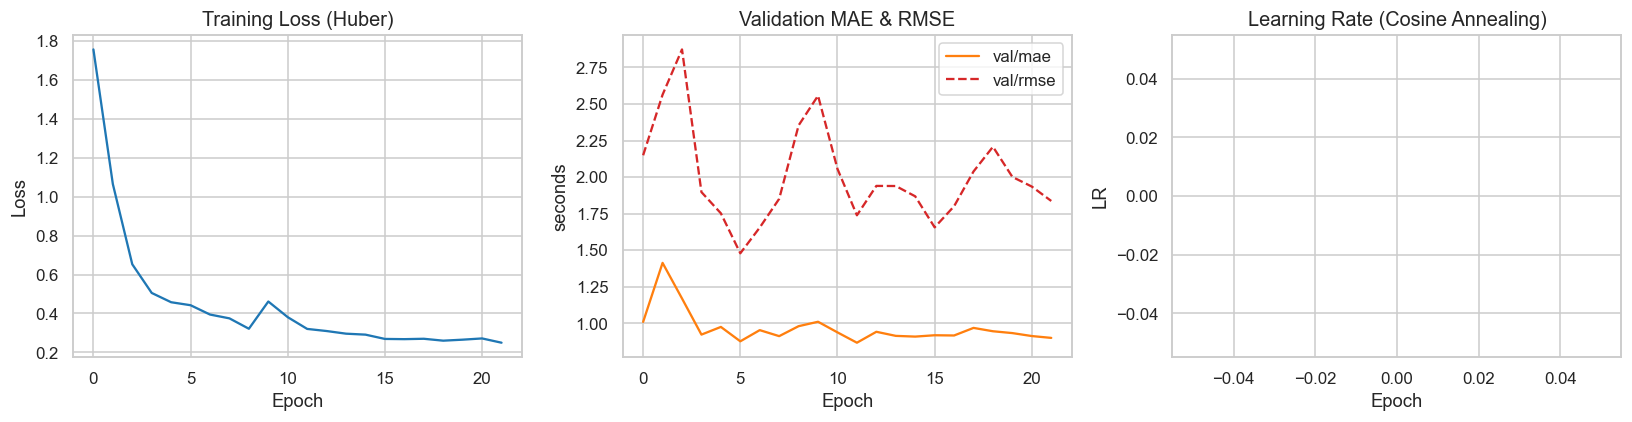


Final val/mae  : 0.8661 s
Final val/rmse : 1.4780 s
Stopped at epoch: 21


In [22]:
# ── Load CSV logs ──────────────────────────────────────────────────────────────
log_dir_prod = sorted(LOG_DIR.glob('tcn_prod_phase1/version_*'))[-1]
metrics      = pd.read_csv(log_dir_prod / 'metrics.csv')

# Epoch-level columns
train_loss = metrics[['epoch', 'train/loss_epoch']].dropna()
val_mae    = metrics[['epoch', 'val/mae']].dropna()
val_rmse   = metrics[['epoch', 'val/rmse']].dropna()
lr_curve   = metrics[['epoch', 'lr-AdamW']].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_loss['epoch'], train_loss['train/loss_epoch'], label='train/loss')
axes[0].set_title('Training Loss (Huber)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(val_mae['epoch'], val_mae['val/mae'], color='tab:orange', label='val/mae')
axes[1].plot(val_rmse['epoch'], val_rmse['val/rmse'], color='tab:red', linestyle='--', label='val/rmse')
axes[1].set_title('Validation MAE & RMSE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('seconds')
axes[1].legend()

axes[2].plot(lr_curve['epoch'], lr_curve['lr-AdamW'], color='tab:green')
axes[2].set_title('Learning Rate (Cosine Annealing)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')

plt.tight_layout()
plt.savefig(outputs_path / 'phase1a_training_curves.png', dpi=110)
plt.show()

print(f'\nFinal val/mae  : {val_mae["val/mae"].min():.4f} s')
print(f'Final val/rmse : {val_rmse["val/rmse"].min():.4f} s')
print(f'Stopped at epoch: {int(train_loss["epoch"].max())}')


### Step 6 — Model A Phase 1a Observations

> **Pending re-run** — hyperparameters updated to v2 (`d_model=128`, `dropout=0.2`, `lr=3e-4`,
> `weight_decay=1e-3`, `patience=15`). Results below are from v1 for reference.

**v1 results:** val/MAE = **0.866 s** · val/RMSE = **1.478 s** · stopped at epoch **21**

**vs. the per-stint baseline (same architecture, same data, one sample per stint):**

| | Per-stint (legacy) | Per-lap v1 | Per-lap v2 (pending) |
|---|---|---|---|
| val/MAE | 1.563 s | 0.866 s | — |
| val/RMSE | 3.372 s | 1.478 s | — |
| Training samples | 1,081 | 20,363 | 20,363 |

The entire v1 gain came from per-lap sampling alone. v2 targets further improvement
through a larger model and more conservative optimisation.

**v1 training dynamics:**
- Loss dropped steeply from 1.8 → 0.6 in the first 5 epochs, continuing to ~0.25 at epoch 21.
  Still slightly descending at early stop — the model hadn't saturated, but val/MAE plateaued.
- val/MAE stable around 0.87 s after epoch 4 — good generalisation on 2024.
- val/RMSE noisier (spikes at epochs 2 and 9) — outlier stints (SC, anomalous degradation)
  inflate RMSE. RMSE/MAE ratio ≈ 1.7× (was 2.1× with per-stint sampling).

**LR plot bug:** `lr-AdamW` stored with NaN in most CSVLogger rows — degenerate scatter
is cosmetic, not a training issue.


---

## Step 7 — Model B: Phase 1 (Pure features, incremental target, train 2023, val 2024)

Model B predicts **per-lap degradation rate** (`tcn_wear_rate = ΔFuelAdjustedDegAbsolute`),
the incremental change in tire wear between consecutive laps. This is a fundamentally
different prediction target from Model A:

| | Model A | Model B |
|---|---|---|
| Target | `FuelAdjustedDegAbsolute[t]` (cumulative) | `ΔFuelAdjustedDegAbsolute[t]` (incremental) |
| Feature set | Production (42 features) | Pure (without Cat2 features) |
| HuberLoss δ | 1.0 s | 0.1 s (incremental scale ~0.05 s/lap) |
| Fine-tuning | Global → per-compound (N10) | Global only |

Model B's output (`tcn_wear_rate`) is qualitatively different from the noisy rolling
3-lap polyfit (`DegradationRate`) already in the feature set: it is forward-looking,
uses 28 laps of race history, and is physically grounded in the TCN's learned dynamics.

Phase 1 trains on 2023 and validates on 2024 to determine the optimal stopping epoch.


In [ ]:
dm_modelB_p1 = TireDegDataModule(
    df=df, phase='phase1', feature_set='pure',
    target_mode=TARGET_INCREMENTAL, batch_size=128,
)

lit_modelB_p1 = TireDegLitModule(
    n_features=len(PURE_FEATURES),
    d_model=128,        # v2: 64 → 128
    n_layers=4,
    kernel_size=3,
    dropout=0.2,        # v2: 0.1 → 0.2
    lr=3e-4,            # v2: 1e-3 → 3e-4
    weight_decay=1e-3,  # v2: 1e-4 → 1e-3
    huber_delta=0.1,    # incremental scale ~0.05 s/lap
    t_max=100,
)

trainer_modelB_p1 = L.Trainer(
    max_epochs=100,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    callbacks=[
        EarlyStopping(monitor='val/mae', patience=15, mode='min', verbose=True),  # v2: 10 → 15
        ModelCheckpoint(
            monitor='val/mae', mode='min',
            filename='tiredeg_modelB_phase1_{epoch:02d}_{val/mae:.4f}',
            save_top_k=1,
        ),
        LearningRateMonitor(logging_interval='epoch'),
    ],
    logger=CSVLogger(LOG_DIR, name='tcn_modelB_phase1'),
    log_every_n_steps=1,
    enable_progress_bar=True,
)

trainer_modelB_p1.fit(lit_modelB_p1, datamodule=dm_modelB_p1)

best_ckpt_B = trainer_modelB_p1.checkpoint_callback.best_model_path
best_mae_B  = trainer_modelB_p1.checkpoint_callback.best_model_score
print(f'\nBest checkpoint : {os.path.basename(best_ckpt_B)}')
print(f'Best val/mae    : {best_mae_B:.4f} s/lap')


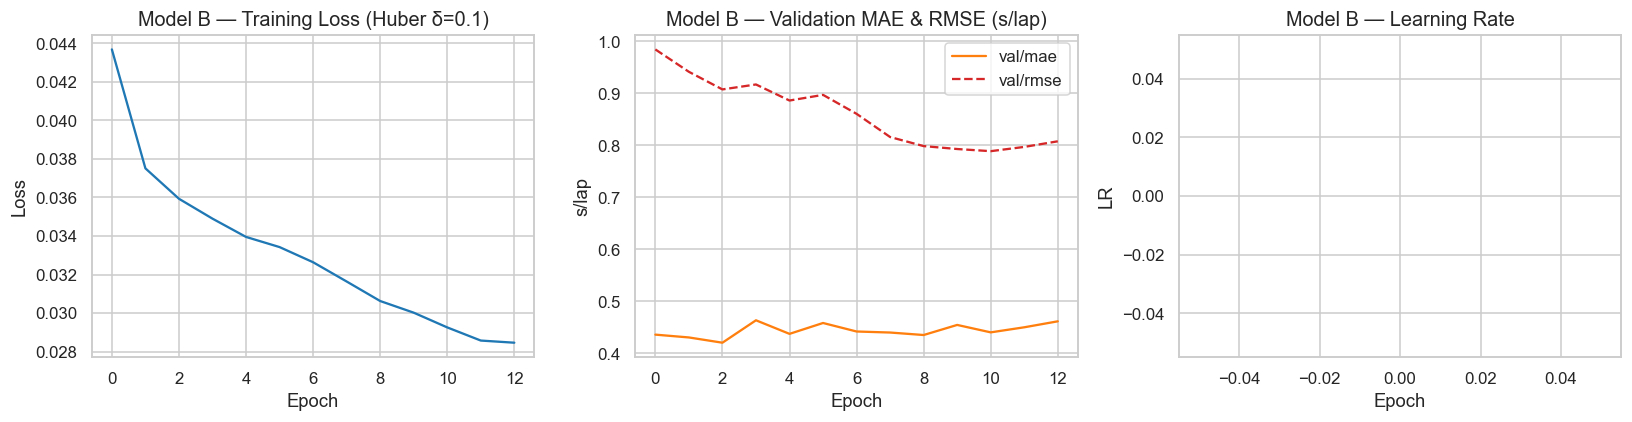


Best val/mae  : 0.4204 s/lap
Stopped at epoch: 12


In [24]:
# ── Load CSV logs ──────────────────────────────────────────────────────────────
log_dir_modelB_p1 = sorted(LOG_DIR.glob('tcn_modelB_phase1/version_*'))[-1]
metrics_B = pd.read_csv(log_dir_modelB_p1 / 'metrics.csv')

train_loss_B = metrics_B[['epoch', 'train/loss_epoch']].dropna()
val_mae_B    = metrics_B[['epoch', 'val/mae']].dropna()
val_rmse_B   = metrics_B[['epoch', 'val/rmse']].dropna()
lr_B         = metrics_B[['epoch', 'lr-AdamW']].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_loss_B['epoch'], train_loss_B['train/loss_epoch'])
axes[0].set_title('Model B — Training Loss (Huber δ=0.1)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(val_mae_B['epoch'], val_mae_B['val/mae'], color='tab:orange', label='val/mae')
axes[1].plot(val_rmse_B['epoch'], val_rmse_B['val/rmse'], color='tab:red', linestyle='--', label='val/rmse')
axes[1].set_title('Model B — Validation MAE & RMSE (s/lap)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('s/lap')
axes[1].legend()

axes[2].plot(lr_B['epoch'], lr_B['lr-AdamW'], color='tab:green')
axes[2].set_title('Model B — Learning Rate')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')

plt.tight_layout()
plt.savefig(outputs_path / 'modelB_phase1_training_curves.png', dpi=110)
plt.show()

print(f'\nBest val/mae  : {val_mae_B["val/mae"].min():.4f} s/lap')
print(f'Stopped at epoch: {int(train_loss_B["epoch"].max())}')


### Step 7.1 — Model B Phase 1 Observations

> **Pending re-run** — hyperparameters updated to v2 (`d_model=128`, `dropout=0.2`, `lr=3e-4`,
> `weight_decay=1e-3`, `patience=15`). Results below are from v1 for reference.

**v1 results:** val/MAE = **0.420 s/lap** · stopped at epoch **12**

| | v1 | v2 (pending) |
|---|---|---|
| val/MAE | 0.420 s/lap | — |
| Stopped epoch | 12 | — |

**v1 notes:** val/RMSE was still trending down (1.0→0.80 s/lap) at early stop. With patience=15
in v2, the model has more room to improve tail errors. Loss curve was very smooth — the
incremental target converges cleanly with `huber_delta=0.1`.


### Step 7.2 — Model B: Phase 2 (train 2023+2024, test 2025)

Phase 2 trains Model B on 2023+2024 using the epoch count from Phase 1's early-stop + 5.
No early stopping is used; the cosine LR cycle is scaled to `N_EPOCHS_B_P2`.
Test metrics on 2025 are the definitive Model B numbers for the TFG.


In [ ]:
B_STOPPED_EPOCH = int(trainer_modelB_p1.current_epoch)
N_EPOCHS_B_P2   = B_STOPPED_EPOCH * 2  # v2: stopped+5 → stopped×2 (loss still declining in v1)

dm_modelB_p2 = TireDegDataModule(
    df=df, phase='phase2', feature_set='pure',
    target_mode=TARGET_INCREMENTAL, batch_size=128,
)

lit_modelB_p2 = TireDegLitModule(
    n_features=len(PURE_FEATURES),
    d_model=128,
    n_layers=4, kernel_size=3,
    dropout=0.2, lr=3e-4, weight_decay=1e-3,
    huber_delta=0.1, t_max=N_EPOCHS_B_P2,
)

trainer_modelB_p2 = L.Trainer(
    max_epochs=N_EPOCHS_B_P2,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    callbacks=[
        ModelCheckpoint(
            monitor='train/loss_epoch', mode='min',
            filename='tiredeg_modelB_phase2_{epoch:02d}',
            save_top_k=1,
            save_last=True,
        ),
        LearningRateMonitor(logging_interval='epoch'),
    ],
    logger=CSVLogger(LOG_DIR, name='tcn_modelB_phase2'),
    log_every_n_steps=1,
    enable_progress_bar=True,
)

print(f'Model B Phase 2 — training for {N_EPOCHS_B_P2} epochs on 2023+2024, testing on 2025')
trainer_modelB_p2.fit(lit_modelB_p2, datamodule=dm_modelB_p2)

test_results_B = trainer_modelB_p2.test(lit_modelB_p2, datamodule=dm_modelB_p2, verbose=True)
r_B = test_results_B[0]
print(f"\n{'─'*40}")
print(f"Model B Phase 2 — Final metrics on 2025 holdout")
print(f"  MAE  : {r_B['test/mae']:.4f} s/lap")
print(f"  RMSE : {r_B['test/rmse']:.4f} s/lap")
print(f"  R²   : {r_B['test/r2']:.4f}")
print(f"{'─'*40}")


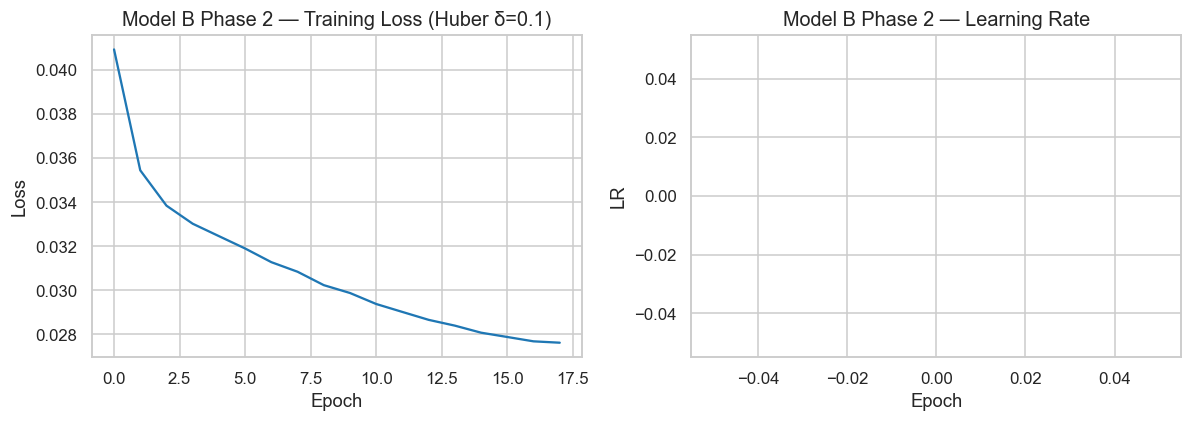

In [26]:
# ── Load CSV logs ──────────────────────────────────────────────────────────────
log_dir_B_p2 = sorted(LOG_DIR.glob('tcn_modelB_phase2/version_*'))[-1]
metrics_B_p2 = pd.read_csv(log_dir_B_p2 / 'metrics.csv')

train_loss_B2 = metrics_B_p2[['epoch', 'train/loss_epoch']].dropna()
lr_B2         = metrics_B_p2[['epoch', 'lr-AdamW']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(train_loss_B2['epoch'], train_loss_B2['train/loss_epoch'])
axes[0].set_title('Model B Phase 2 — Training Loss (Huber δ=0.1)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(lr_B2['epoch'], lr_B2['lr-AdamW'], color='tab:green')
axes[1].set_title('Model B Phase 2 — Learning Rate')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR')

plt.tight_layout()
plt.savefig(outputs_path / 'modelB_phase2_training_curves.png', dpi=110)
plt.show()


### Step 7.2 — Model B Phase 2 Observations

> **Pending re-run** — hyperparameters updated to v2. Results below are from v1 for reference.

**v1 results on 2025 holdout:** MAE = **0.429 s/lap** · RMSE = **0.666 s/lap** · R² = **0.174**

The +0.009 s/lap gap between v1 val and test confirmed good generalisation. v2 targets
improvement in R² through the wider model and longer Phase 2 budget (`stopped × 2` epochs).

**On R² = 0.17 (v1):** expected for an incremental target dominated by noise (SC laps,
pit transitions, track evolution). Model B's value is `tcn_wear_rate` as a downstream
feature, not its standalone R².


---

## Step 8 — Model A: Phase 2 (train 2023+2024, test 2025)

Phase 2 is the definitive run for **Model A** (production features, cumulative target).
Two years of data are used for training (2023+2024), and 2025 is the held-out test set —
never seen during training or hyperparameter search.

There is no validation set in Phase 2, so `EarlyStopping` is not used. Instead, we
train for the same number of epochs Phase 1a ran before early stopping, plus a small
buffer (`+5`). The cosine annealing cycle is adjusted to match `t_max=N_EPOCHS_P2`
so the LR reaches `eta_min` exactly at the last epoch.

After `trainer.fit()`, `trainer.test()` runs one pass over the 2025 split and logs
`test/mae`, `test/rmse`, and `test/r2` — the three numbers reported in the TFG.


In [ ]:
import os

P1_STOPPED_EPOCH = int(trainer_prod.current_epoch)
N_EPOCHS_P2 = P1_STOPPED_EPOCH * 2  # v2: stopped+5 → stopped×2 (loss still declining in v1)

dm_phase2 = TireDegDataModule(
    df=df, phase='phase2', feature_set='production',
    target_mode=TARGET_CUMULATIVE, batch_size=128,
)

lit_phase2 = TireDegLitModule(
    n_features=len(PRODUCTION_FEATURES),
    d_model=128,
    n_layers=4, kernel_size=3,
    dropout=0.2, lr=3e-4, weight_decay=1e-3,
    huber_delta=1.0, t_max=N_EPOCHS_P2,
)

trainer_phase2 = L.Trainer(
    max_epochs=N_EPOCHS_P2,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    callbacks=[
        ModelCheckpoint(
            monitor='train/loss_epoch', mode='min',
            filename='tiredeg_prod_phase2_{epoch:02d}',
            save_top_k=1,
            save_last=True,
        ),
        LearningRateMonitor(logging_interval='epoch'),
    ],
    logger=CSVLogger(LOG_DIR, name='tcn_prod_phase2'),
    log_every_n_steps=1,
    enable_progress_bar=True,
)

print(f'Model A Phase 2 — training for {N_EPOCHS_P2} epochs on 2023+2024, testing on 2025')
trainer_phase2.fit(lit_phase2, datamodule=dm_phase2)

test_results = trainer_phase2.test(lit_phase2, datamodule=dm_phase2, verbose=True)
r = test_results[0]
print(f"\n{'─'*40}")
print(f"Model A Phase 2 — Final metrics on 2025 holdout")
print(f"  MAE  : {r['test/mae']:.4f} s")
print(f"  RMSE : {r['test/rmse']:.4f} s")
print(f"  R²   : {r['test/r2']:.4f}")
print(f"{'─'*40}")


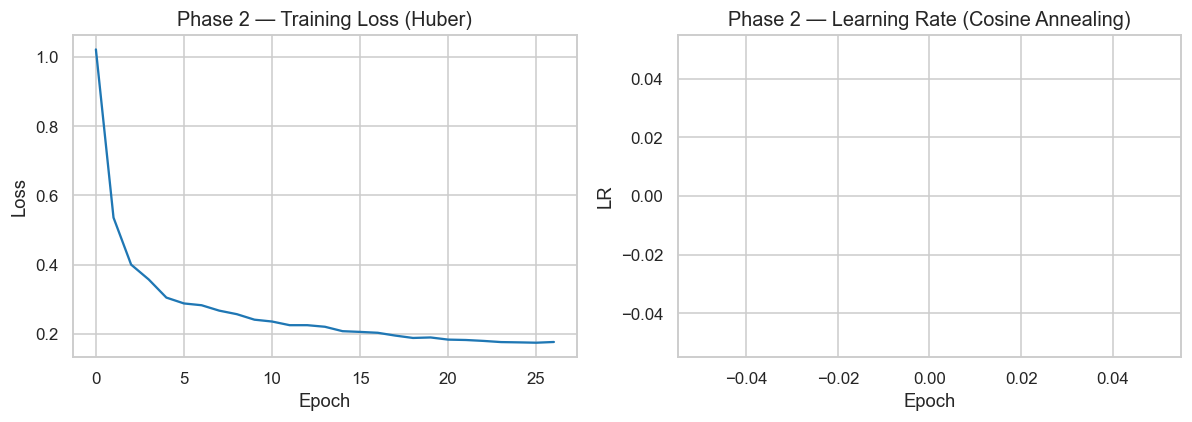

In [28]:
# ── Load CSV logs ──────────────────────────────────────────────────────────────
log_dir_p2   = sorted(LOG_DIR.glob('tcn_prod_phase2/version_*'))[-1]
metrics_p2   = pd.read_csv(log_dir_p2 / 'metrics.csv')

train_loss_p2 = metrics_p2[['epoch', 'train/loss_epoch']].dropna()
lr_p2         = metrics_p2[['epoch', 'lr-AdamW']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(train_loss_p2['epoch'], train_loss_p2['train/loss_epoch'])
axes[0].set_title('Phase 2 — Training Loss (Huber)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(lr_p2['epoch'], lr_p2['lr-AdamW'], color='tab:green')
axes[1].set_title('Phase 2 — Learning Rate (Cosine Annealing)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR')

plt.tight_layout()
plt.savefig(outputs_path / 'phase2_training_curves.png', dpi=110)
plt.show()


### Step 8 — Model A Phase 2 Observations

> **Pending re-run** — hyperparameters updated to v2. Results below are from v1 for reference.

**v1 results on 2025 holdout:** MAE = **0.708 s** · RMSE = **1.123 s** · R² = **0.605**

| | Phase 1a v1 val | Phase 2 v1 test | Phase 2 v2 (pending) |
|---|---|---|---|
| MAE | 0.866 s | 0.708 s | — |
| RMSE | 1.478 s | 1.123 s | — |
| R² | — | 0.605 | — |

v1 was the primary TFG baseline: R²=0.605 on a fully unseen 2025 holdout, global model,
no per-compound specialisation. v2 targets improvement across all three metrics via the
wider model (`d_model=128`) and doubled Phase 2 epoch budget. Per-compound fine-tuning
in N10 is the next expected R² jump.
